# Part 1: Attrition Prediction

## Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Import Dataset

In [5]:
# Load dataset (adjust path if needed)
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head(10).style.background_gradient(cmap='Reds')

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [6]:
df.isnull().sum()  # The dataset does not contain any null entries

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Correlation Heatmap


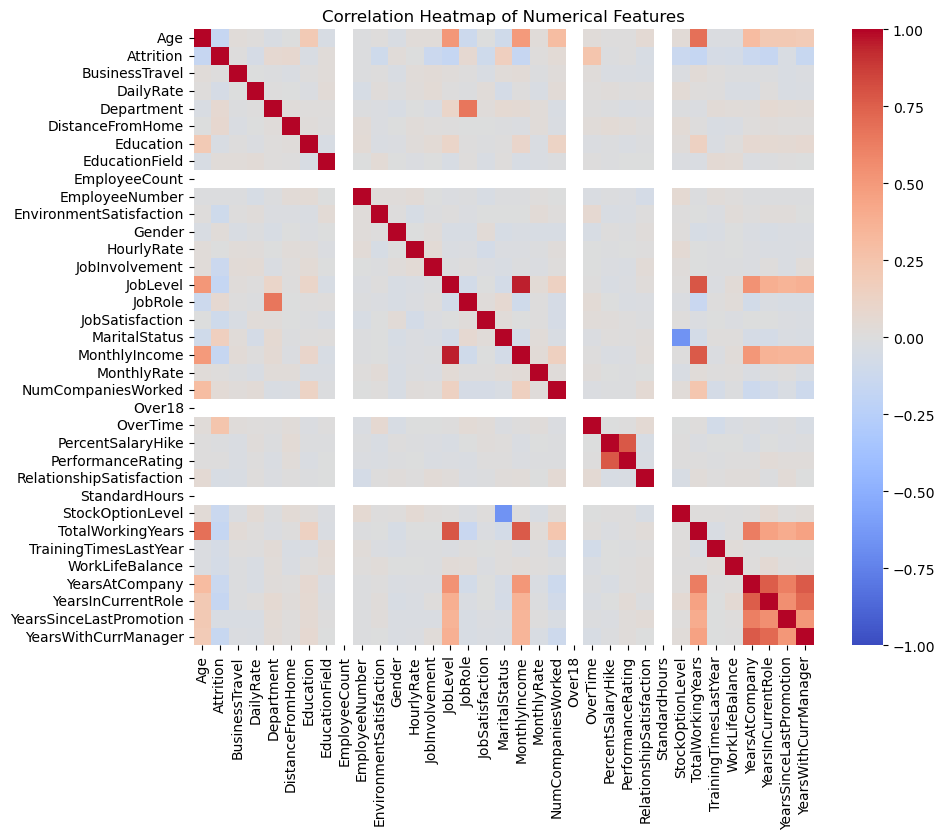

In [29]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Encode and Split the Dataset for Classification

In [27]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical features
df_encoded = df.copy()
le = LabelEncoder()
for column in df_encoded.select_dtypes(include='object'):
    df_encoded[column] = le.fit_transform(df_encoded[column])

# Classification target(dep and indep)
X_cls = df_encoded.drop(['Attrition', 'EmployeeNumber', 'MonthlyIncome'], axis=1)
y_cls = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

In [31]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

## Standardize the Data

In [34]:
from sklearn.preprocessing import StandardScaler

# Step 1: Scale the feature data (retain column names)
scaler = StandardScaler()
X_train_cls_scaled = pd.DataFrame(scaler.fit_transform(X_train_cls), columns=X_train_cls.columns)
X_test_cls_scaled = pd.DataFrame(scaler.transform(X_test_cls), columns=X_test_cls.columns)

## Train the Logistic Regression Model on the Training Data

In [37]:
from sklearn.linear_model import LogisticRegression

# Step 2: Train Logistic Regression on scaled data
clf = LogisticRegression(max_iter=1000, solver='lbfgs')
clf.fit(X_train_cls_scaled, y_train_cls)

LogisticRegression(max_iter=1000)

In [39]:
#Step 3: Make predictions
y_pred_cls = clf.predict(X_test_cls_scaled)
y_proba_cls = clf.predict_proba(X_test_cls_scaled)[:, 1]

## Evaluation Metrics

In [42]:
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve, auc

# Step 4: Evaluate performance
f1 = f1_score(y_test_cls, y_pred_cls)
roc_auc = roc_auc_score(y_test_cls, y_proba_cls)
precision, recall, _ = precision_recall_curve(y_test_cls, y_proba_cls)
pr_auc = auc(recall, precision)

# Print results
print("Logistic Regression Performance:")
print(f"  F1-score:       {f1:.4f}")
print(f"  AUC-ROC:        {roc_auc:.4f}")
print(f"  PR AUC:         {pr_auc:.4f}")

Logistic Regression Performance:
  F1-score:       0.4211
  AUC-ROC:        0.7696
  PR AUC:         0.5136


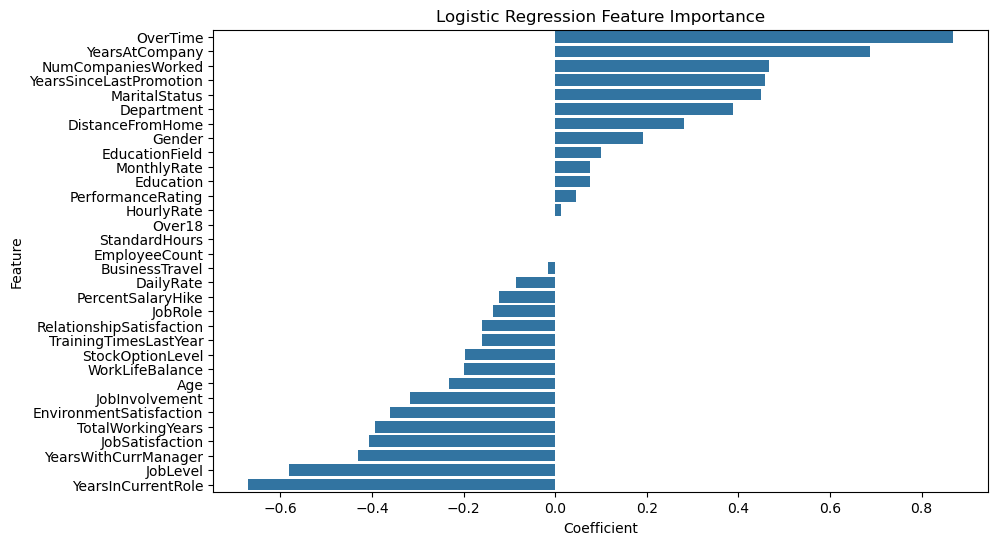

In [44]:
coef_df = pd.DataFrame({
    'Feature': X_train_cls.columns,
    'Coefficient': clf.coef_[0]
}).sort_values('Coefficient', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df)
plt.title('Logistic Regression Feature Importance')
plt.show()

## Making the Confusion Matrix

<Figure size 500x400 with 0 Axes>

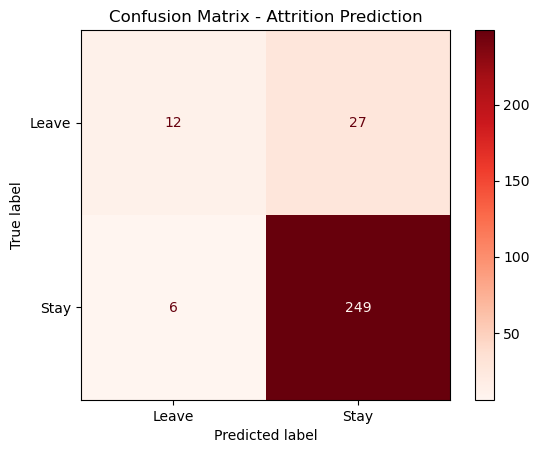

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate confusion matrix
cm = confusion_matrix(y_test_cls, y_pred_cls, labels=[1, 0])  # [1 = 'Yes'/Leave, 0 = 'No'/Stay]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Leave", "Stay"])

# Plot
plt.figure(figsize=(5, 4))
disp.plot(cmap="Reds", values_format='d')
plt.title("Confusion Matrix - Attrition Prediction")
plt.show()


## Train the SVM Classifier Model on the Training Data

In [50]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Train SVM
svm_clf = SVC(probability=True, kernel='rbf', random_state=42)
svm_clf.fit(X_train_cls_scaled, y_train_cls)

# Predictions and probabilities
y_pred_svm = svm_clf.predict(X_test_cls_scaled)
y_proba_svm = svm_clf.predict_proba(X_test_cls_scaled)[:, 1]


## Evaluation Metrics

In [53]:
# Evaluate SVM
f1_svm = f1_score(y_test_cls, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test_cls, y_proba_svm)
precision_svm, recall_svm, _ = precision_recall_curve(y_test_cls, y_proba_svm)
pr_auc_svm = auc(recall_svm, precision_svm)
accuracy_svm = accuracy_score(y_test_cls, y_pred_svm)
recall_score_svm = recall_score(y_test_cls, y_pred_svm)
precision_score_svm = precision_score(y_test_cls, y_pred_svm)

print("\nSVM Performance:")
print(f"  Accuracy:       {accuracy_svm:.4f}")
print(f"  F1-score:       {f1_svm:.4f}")
print(f"  Recall:         {recall_score_svm:.4f}")
print(f"  Precision:      {precision_score_svm:.4f}")
print(f"  AUC-ROC:        {roc_auc_svm:.4f}")
print(f"  PR AUC:         {pr_auc_svm:.4f}")


SVM Performance:
  Accuracy:       0.8878
  F1-score:       0.2667
  Recall:         0.1538
  Precision:      1.0000
  AUC-ROC:        0.7952
  PR AUC:         0.5389


## Making the Confusion Matrix

<Figure size 500x400 with 0 Axes>

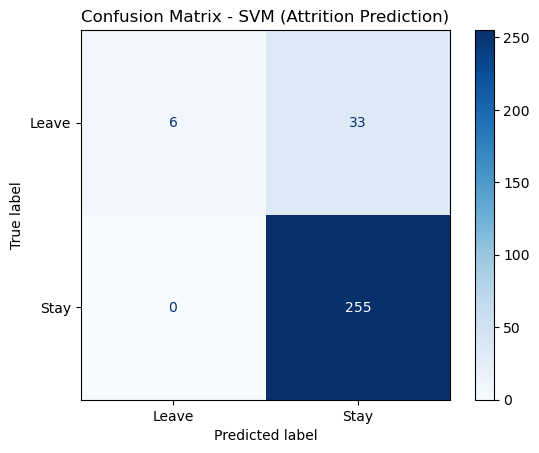

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_svm = confusion_matrix(y_test_cls, y_pred_svm, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Leave", "Stay"])

# Plot
plt.figure(figsize=(5, 4))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - SVM (Attrition Prediction)")
plt.show()



# Classification Model Comparision

## ROC Curve Comparison: Logistic Regression vs SVM

In [60]:
# Get predicted probabilities
y_pred_proba = clf.predict_proba(X_test_cls_scaled)[:, 1]
y_pred_proba_svm = svm_clf.predict_proba(X_test_cls_scaled)[:, 1]

from sklearn.metrics import roc_curve, auc

# Logistic Regression ROC
fpr, tpr, _ = roc_curve(y_test_cls, y_pred_proba)
roc_auc = auc(fpr, tpr)

# SVM ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test_cls, y_pred_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)


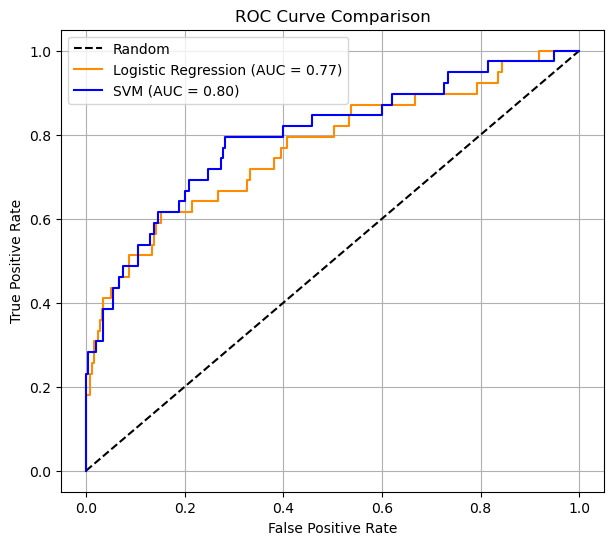

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

# ROC Curve
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.plot(fpr, tpr, color='darkorange', label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot(fpr_svm, tpr_svm, color='blue', label=f'SVM (AUC = {roc_auc_svm:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


## Precision-Recall Curve Comparison: Logistic Regression vs SVM

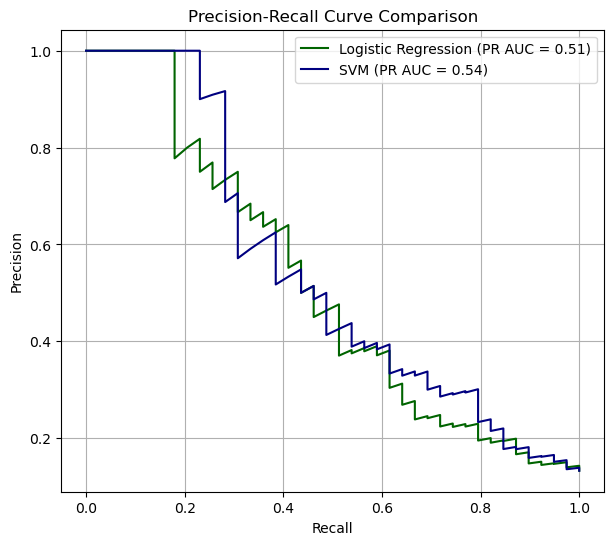

In [65]:
plt.figure(figsize=(7, 6))

# Precision-Recall Curve
plt.plot(recall, precision, color='darkgreen', label=f'Logistic Regression (PR AUC = {pr_auc:.2f})')
plt.plot(recall_svm, precision_svm, color='navy', label=f'SVM (PR AUC = {pr_auc_svm:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


In [67]:
## Comparing both Models

In [69]:
print("\nBest Classification Model:")
if f1_svm > f1:
    print("SVM performed better based on F1-score.")
else:
    print("Logistic Regression performed better based on F1-score.")



Best Classification Model:
Logistic Regression performed better based on F1-score.


# Part 2: Simulating Future Salaries

In [72]:
# Performance-based increment simulation
df["Increment"] = df["PerformanceRating"].apply(lambda x: 1.10 if x == 4 else 1.05)
df["FutureSalary"] = df["MonthlyIncome"] * df["Increment"]


### Visualizing Salary Growth from Performance-Based Simulation

The bar chart below compares the **current monthly salary** with the **future projected salary** based on performance-based increments.
- Employees with top performance ratings (rating = 4) receive a 10% increase.
- Others receive a 5% increase.

This simulation provides a quick insight into how performance-linked policies can impact salary distribution across employees.


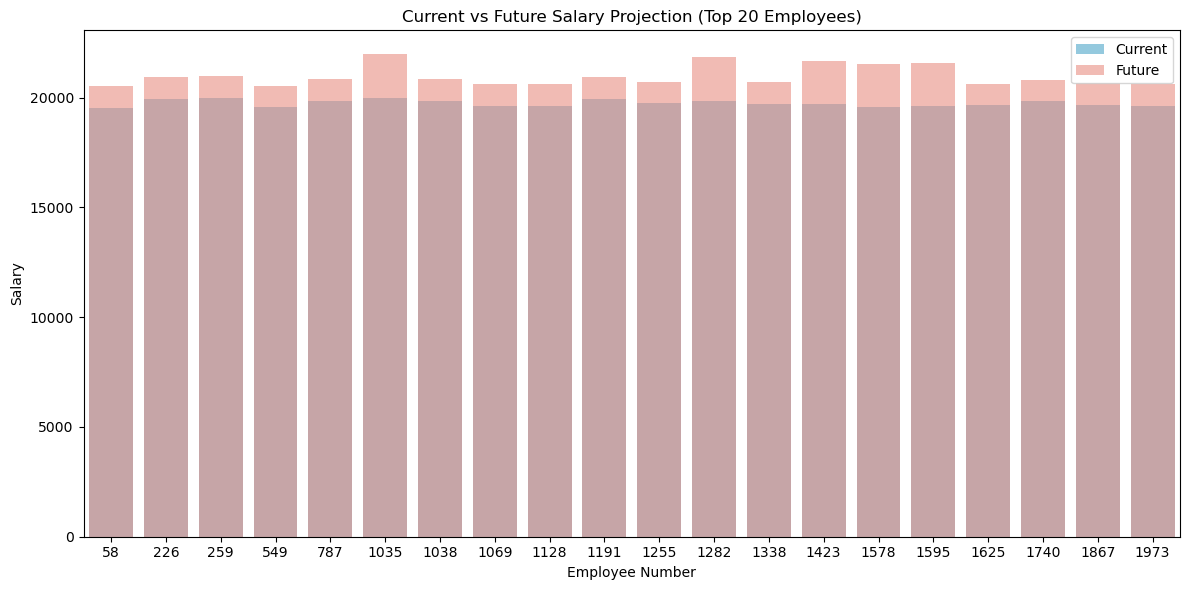

In [75]:
# Visualize current vs future salaries
import matplotlib.pyplot as plt
import seaborn as sns

df_sorted = df.sort_values(by="MonthlyIncome", ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x="EmployeeNumber", y="MonthlyIncome", data=df_sorted, color="skyblue", label="Current")
sns.barplot(x="EmployeeNumber", y="FutureSalary", data=df_sorted, color="salmon", label="Future", alpha=0.6)

plt.xlabel("Employee Number")
plt.ylabel("Salary")
plt.title("Current vs Future Salary Projection (Top 20 Employees)")
plt.legend()
plt.tight_layout()
plt.show()


# Part 3: Salary Prediction

## Encode the Data and Split the Data

In [79]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include='object'):
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

# Define features and target
X_reg = df_encoded.drop(columns=["FutureSalary", "Increment"])
y_reg = df_encoded["FutureSalary"]

In [81]:
from sklearn.model_selection import train_test_split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)


In [83]:
!pip install xgboost


## Train the Random Forest Regressor on the Training Data

In [85]:
from sklearn.ensemble import RandomForestRegressor
# Train the regression model
reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train_reg, y_train_reg)

RandomForestRegressor(random_state=42)

## Evaluation Metrics

In [87]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# Predict using the trained model
y_pred_reg = reg_model.predict(X_test_reg)

# Evaluate performance
r2_rf = r2_score(y_test_reg, y_pred_reg)
rmse_rf = mean_squared_error(y_test_reg, y_pred_reg, squared=False)
mape_rf = mean_absolute_percentage_error(y_test_reg, y_pred_reg)

# Print results
print(f"  R² Score: {r2_rf:.4f}")
print(f"  RMSE:     {rmse_rf:.2f}")
print(f"  MAPE:     {mape_rf:.2%}")


  R² Score: 0.9994
  RMSE:     121.56
  MAPE:     0.76%


# Training the XGBoost Regressor on the Training Data

In [89]:
from xgboost import XGBRegressor

# Train XGBoost Regressor
xgb_model = XGBRegressor(random_state=42, n_estimators=100)
xgb_model.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_reg)

## Evaluation Metrics

In [91]:
from xgboost import XGBRegressor

# Train XGBoost Regressor
xgb_model = XGBRegressor(random_state=42, n_estimators=100)
xgb_model.fit(X_train_reg, y_train_reg)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_reg)

# R² Score
r2_xgb = r2_score(y_test_reg, y_pred_xgb)



# Regression Model Comparision

In [105]:
print("\nBest Regression Model:")
if r2_xgb > r2_rf:
    print("XGBoost performed better based on R² Score.")
else:
    print("Random Forest performed better based on R² Score.")



Best Regression Model:
XGBoost performed better based on R² Score.


# Part 4: Identifying “Likely to Stay” Employees

In [108]:
import pandas as pd

In [110]:
# Scale the full feature set using the original scaler
X_cls_all_scaled = pd.DataFrame(scaler.transform(X_cls), columns=X_cls.columns)

# Predict probabilities using the already-trained logistic regression model
df["P_Attrition"] = clf.predict_proba(X_cls_all_scaled)[:, 1]
df["P_Stay"] = 1 - df["P_Attrition"]

# Filter likely-to-stay employees
likely_to_stay = df[df["P_Stay"] > 0.6]

# Part 5: Estimate Expected Salary Loss

In [113]:
from xgboost import XGBRegressor

In [115]:
# Expected salary loss per employee
df["ExpectedLoss"] = df["P_Attrition"] * df["FutureSalary"]

# Total expected loss across the company
total_expected_loss = df["ExpectedLoss"].sum()
print(f"Total Expected Salary Loss: ₹{total_expected_loss:,.2f}")

Total Expected Salary Loss: ₹1,244,421.75


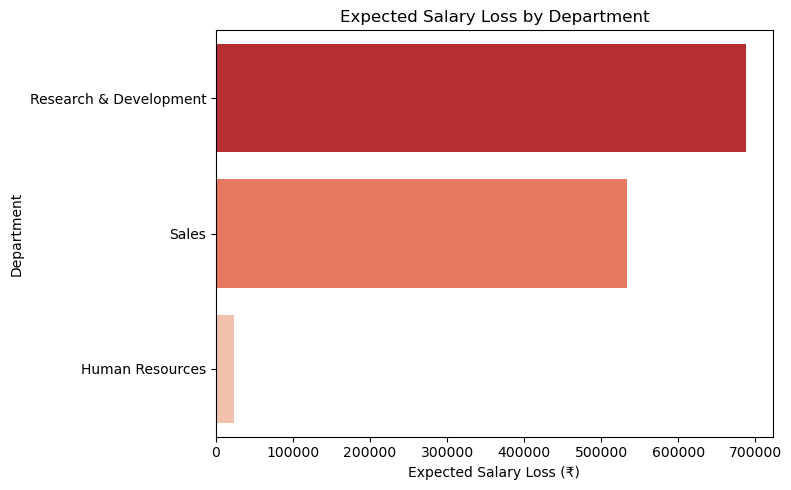

In [117]:
import seaborn as sns

df["ExpectedLoss"] = df["P_Attrition"] * df["FutureSalary"]
loss_by_dept = df.groupby("Department")["ExpectedLoss"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=loss_by_dept.values, y=loss_by_dept.index, hue=loss_by_dept.index,
            palette="Reds_r", legend=False)
plt.xlabel("Expected Salary Loss (₹)")
plt.title("Expected Salary Loss by Department")
plt.tight_layout()
plt.show()


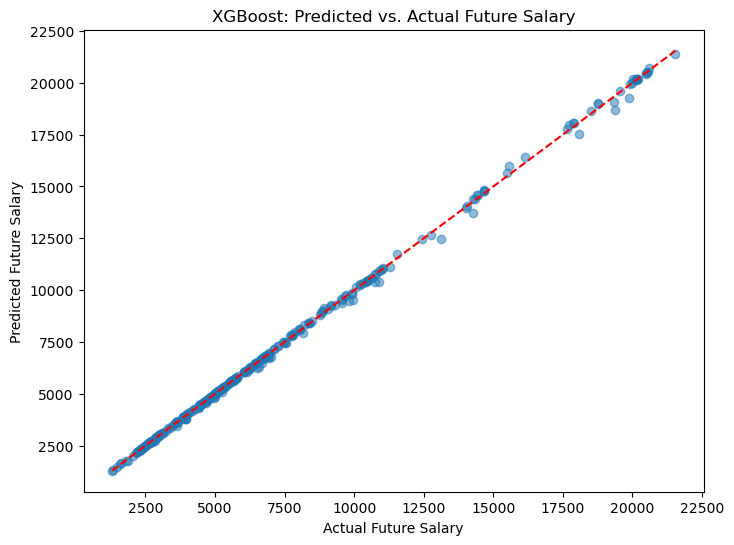

In [119]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Future Salary')
plt.ylabel('Predicted Future Salary')
plt.title('XGBoost: Predicted vs. Actual Future Salary') 
plt.show()


# Future Salary Distribution Plot

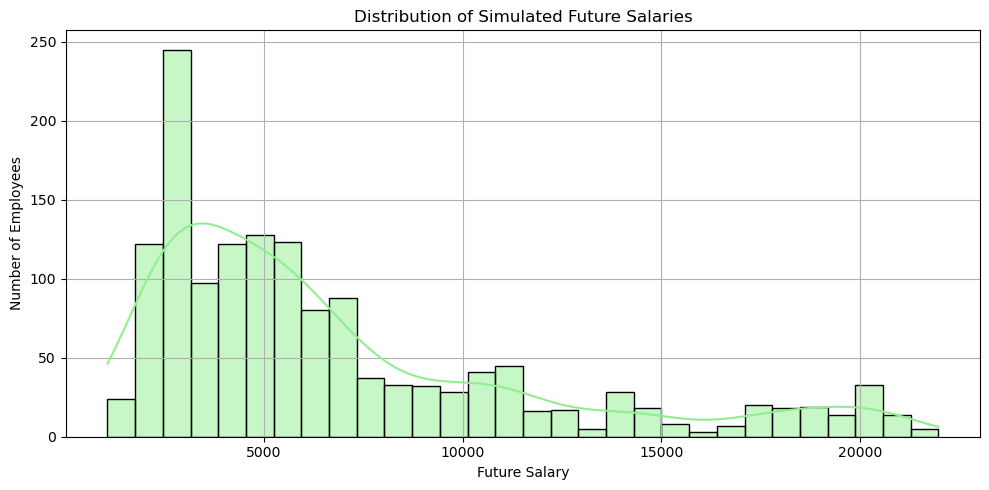

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Clean the column before plotting
df = df.replace([np.inf, -np.inf], np.nan)  # apply to whole DataFrame
df = df.dropna(subset=["FutureSalary"])     # drop rows where FutureSalary is NaN

plt.figure(figsize=(10, 5))
sns.histplot(df["FutureSalary"], bins=30, kde=True, color='lightgreen')
plt.title("Distribution of Simulated Future Salaries")
plt.xlabel("Future Salary")
plt.ylabel("Number of Employees")
plt.grid(True)
plt.tight_layout()
plt.show()


# Conclusion

This project analyzed employee attrition using two supervised learning models: Logistic Regression and Support Vector Machine (SVM). The models were trained on a preprocessed dataset with encoded and standardized features, and their performance was evaluated on a hold-out test set.

Performance was assessed using Accuracy, F1-score, Precision, Recall, ROC AUC, and Precision-Recall AUC, with visualizations including ROC curves, Precision-Recall curves, and confusion matrices.

The Logistic Regression model delivered interpretable coefficients and solid ROC AUC and PR AUC scores.


The SVM model, using an RBF kernel with probability estimates, demonstrated competitive performance, with distinct precision-recall trade-offs.

Confusion matrices for both models showed reasonable detection of the minority class (attrition), though some misclassifications remained, as expected in an imbalanced dataset.

The use of ROC and Precision-Recall curves provided a comprehensive comparison, particularly valuable given the class imbalance.
ce.


# Future Work

- Explore ensemble methods like Random Forest or Gradient Boosting to enhance predictive performance.

- Apply hyperparameter tuning (e.g., Grid Search or Randomized Search) to optimize model configurations.

- Utilize feature importance analysis (e.g., SHAP) to improve model interpretability.

- Implement cost-sensitive learning or resampling techniques to better address class imbalance.

